# Mixture-density LSTM versus LSTM-Quantile versus AR(1)-GARCH(1,1)-$t$ on COVID-19

Notebook 04 ran the LSTM-Quantile head against AR(1)-GARCH(1,1)-$t$ on the COVID OOS window. The LSTM-Quantile outputs $(\widehat{\mathrm{VaR}}_t, \widehat{\mathrm{ES}}_t)$ directly but provides no analytic CDF; only five of the eleven battery tests apply.

The mixture-density LSTM (MDN-LSTM) outputs Student-$t$ parameters $(\mu_t, \sigma_t, \nu_t)$ for the conditional return distribution $F_t$. From those parameters every input the battery needs follows in closed form: the PIT residual $u_t = F_t(Y_t)$, the VaR, the ES and a parametric simulator for the Acerbi-Szekely Monte-Carlo p-values. All eleven base tests now apply, leaving only the two robust Du-Escanciano statistics ($MU_{ES}$, $MC_{ES}$) out of reach (they need the parameter covariance of an MLE fit, which a stochastic-gradient-trained network does not produce in closed form).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from esback.backtests.es_baselines import MDNSimulator, StandardizedTSimulator
from esback.backtests.battery import run_full_battery, battery_dataframe
from esback.config import REPO_ROOT
from esback.data.loaders import load_sp500
from esback.models.dl.lstm_mdn import (
    es_from_mdn, fit_and_forecast_mdn, pit_from_mdn, var_from_mdn,
)
from esback.models.dl.lstm_quantile import fit_and_forecast, select_device
from esback.pipeline import run_period
from esback.risk_measures import es_t, var_t
from esback.viz import figures, style

style.apply_rcparams()
ASSETS_FIG = REPO_ROOT / "assets" / "figures"

alpha = 0.05
device = select_device()
print(f"device = {device}")

device = mps


## Data and split

Same setup as notebook 04: in-sample 2010-01-01 → 2019-12-31, out-of-sample 2020-01-01 → 2021-12-31. The two LSTM models train on the in-sample window and emit one-step-ahead forecasts on the OOS window.

In [2]:
data = load_sp500(start="1997-01-01", end="2024-12-31")
is_mask = (data.index >= "2010-01-01") & (data.index <= "2019-12-31")
oos_mask = (data.index >= "2020-01-01") & (data.index <= "2021-12-31")
n_is = int(is_mask.sum())
n_oos = int(oos_mask.sum())
returns_all = data.loc[is_mask | oos_mask, "Return"].to_numpy(dtype=np.float64)
oos_returns = returns_all[n_is:]
losses = -oos_returns
print(f"n_IS = {n_is}, n_OOS = {n_oos}")

n_IS = 2516, n_OOS = 505


## AR(1)-GARCH(1,1)-$t$ baseline

Same baseline as notebook 04, kept here so the three models can be compared on identical OOS data.

In [3]:
artifacts = run_period(
    data,
    is_start="2010-01-01",
    is_end="2019-12-31",
    oos_end="2021-12-31",
    label="COVID-19 (GARCH-t)",
    alpha_es=alpha,
    alpha_var=alpha,
    m=5,
)
var_garch = var_t(artifacts.forecast.mu_oos, artifacts.forecast.sigma_oos, alpha, artifacts.forecast.nu)
es_garch = es_t(artifacts.forecast.mu_oos, artifacts.forecast.sigma_oos, alpha, artifacts.forecast.nu)
print(f"GARCH-t: nu={artifacts.forecast.nu:.2f}, mean VaR={var_garch.mean():.3f}, mean ES={es_garch.mean():.3f}")

GARCH-t: nu=4.83, mean VaR=1.831, mean ES=2.682


## LSTM-Quantile baseline

Same hyperparameters as notebook 04: 30 epochs, hidden size 32, sequence length 20, Adam at $10^{-3}$, joint pinball + FZ0 loss.

In [4]:
var_lstm, es_lstm, hist_q = fit_and_forecast(
    returns_full=returns_all,
    n_is=n_is,
    alpha=alpha,
    seq_len=20,
    hidden_size=32,
    epochs=30,
    batch_size=64,
    lr=1e-3,
    seed=42,
    device=device,
)
print(f"LSTM-Q: final pinball={hist_q.pinball[-1]:.4f}, fz0={hist_q.fz0[-1]:.4f}")
print(f"        mean VaR={var_lstm.mean():.3f}, mean ES={es_lstm.mean():.3f}")

LSTM-Q: final pinball=0.7906, fz0=0.8943
        mean VaR=0.695, mean ES=2.839


## MDN-LSTM

Same LSTM backbone (sequence length 20, hidden size 32, 30 epochs) but three linear heads on the last hidden state map to the Student-$t$ parameters $(\mu_t, \sigma_t, \nu_t)$. The training objective is the negative log-likelihood of the predicted distribution; the test-time outputs are the closed-form $u_t$, $\widehat{\mathrm{VaR}}_t$ and $\widehat{\mathrm{ES}}_t$.

In [5]:
params, hist_mdn = fit_and_forecast_mdn(
    returns_full=returns_all,
    n_is=n_is,
    seq_len=20,
    hidden_size=32,
    epochs=30,
    batch_size=64,
    lr=1e-3,
    seed=42,
    device=device,
)
loc_mdn, scale_mdn, df_mdn = params["loc"], params["scale"], params["df"]
u_t_mdn = pit_from_mdn(loc_mdn, scale_mdn, df_mdn, oos_returns)
var_mdn = var_from_mdn(loc_mdn, scale_mdn, df_mdn, alpha=alpha)
es_mdn = es_from_mdn(loc_mdn, scale_mdn, df_mdn, alpha=alpha)
print(f"MDN-LSTM: final NLL={hist_mdn.nll[-1]:.4f}")
print(f"          mean mu={loc_mdn.mean():.4f}, mean scale={scale_mdn.mean():.4f}, mean df={df_mdn.mean():.2f}")
print(f"          mean VaR={var_mdn.mean():.3f}, mean ES={es_mdn.mean():.3f}")

MDN-LSTM: final NLL=1.1207
          mean mu=0.1105, mean scale=0.7660, mean df=4.67
          mean VaR=1.445, mean ES=2.136


## Risk paths side-by-side

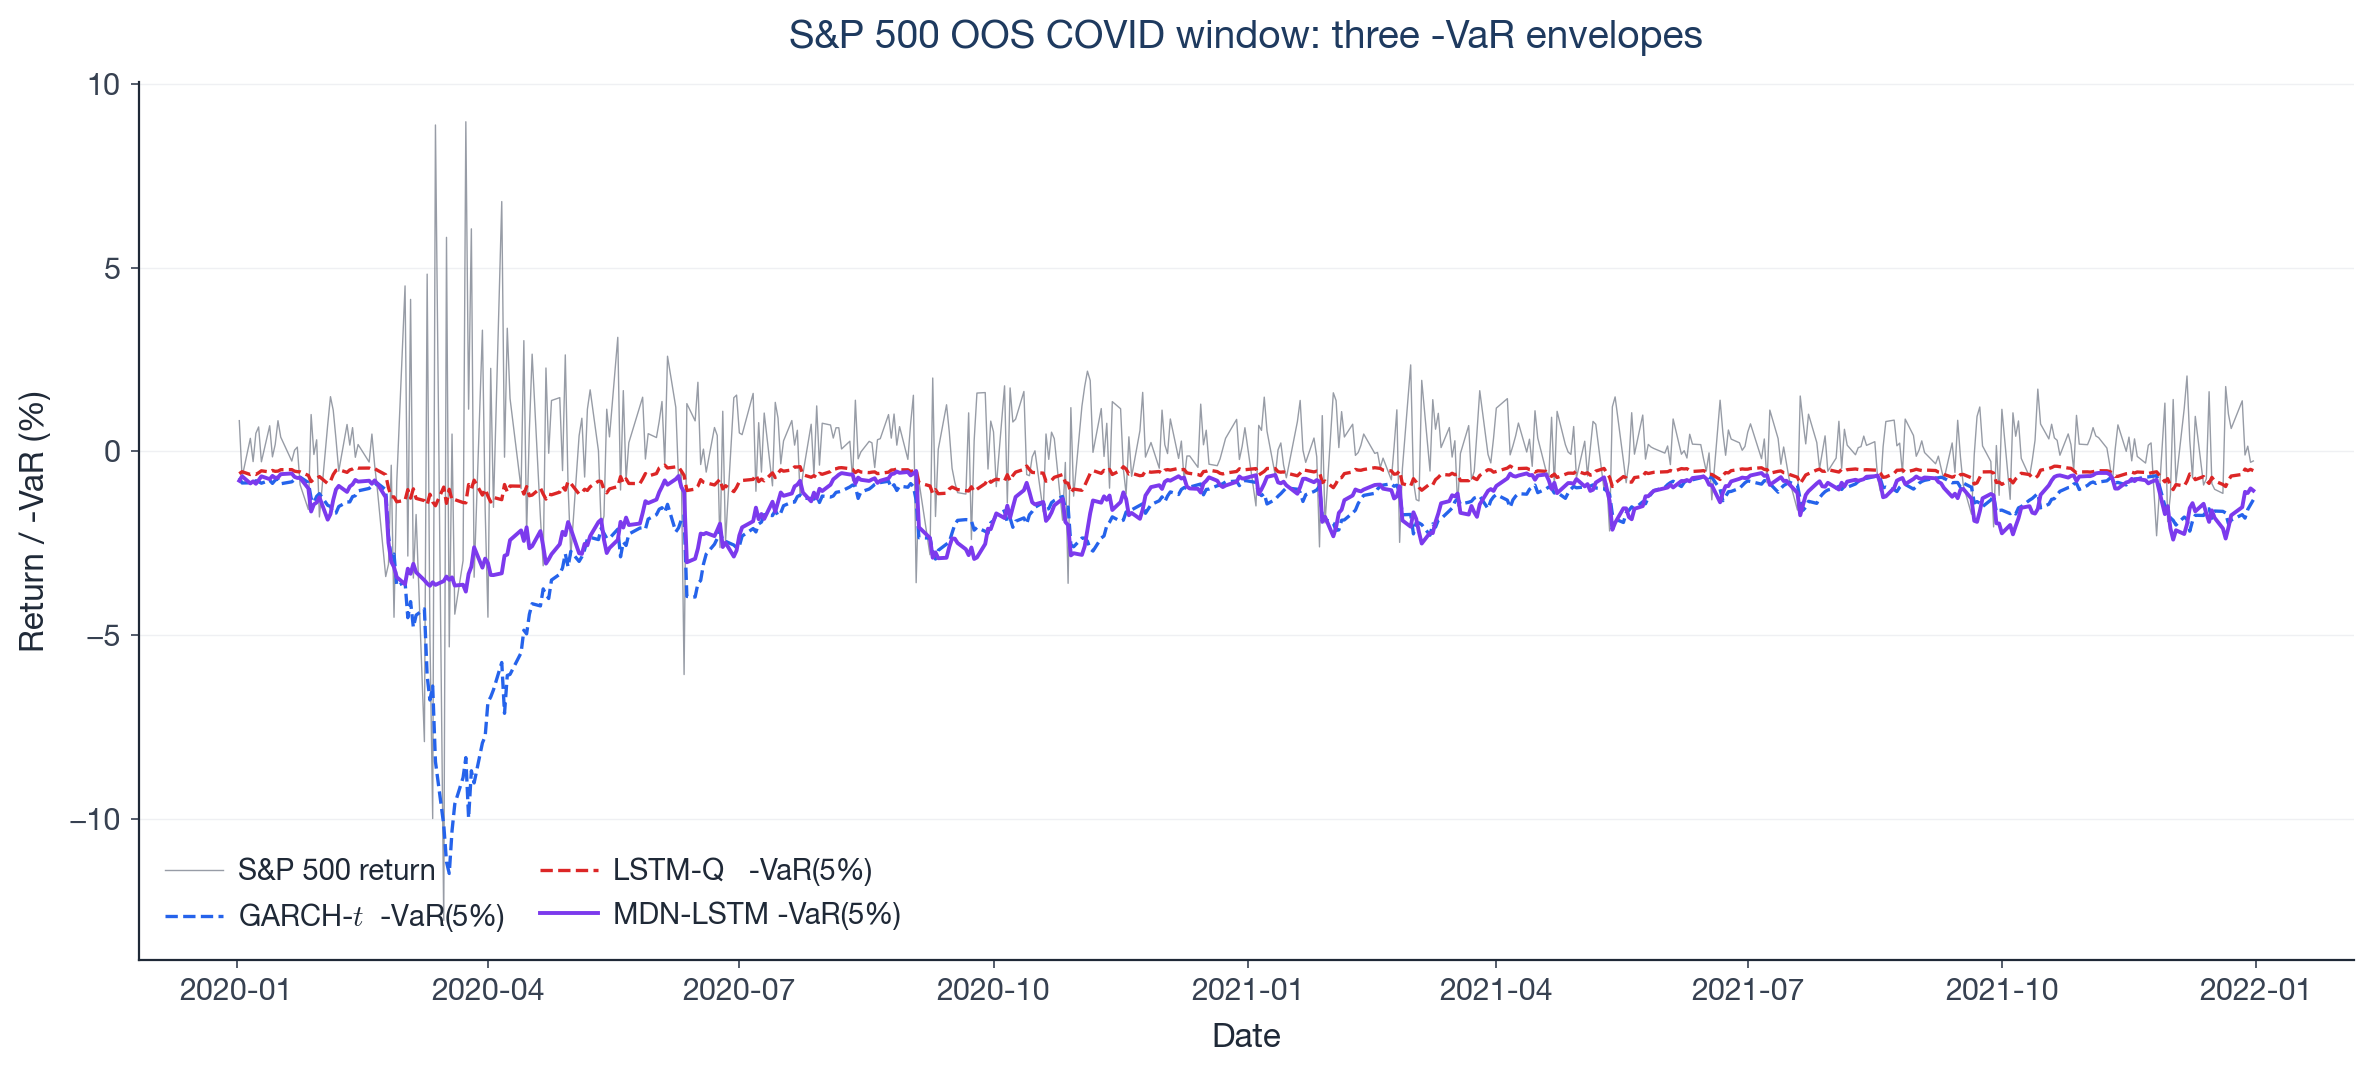

In [6]:
oos_index = artifacts.forecast.oos_index
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(oos_index, oos_returns, color=style.PALETTE["gray"], linewidth=0.5, alpha=0.7, label="S&P 500 return")
ax.plot(oos_index, -var_garch, color=style.PALETTE["blue"], linewidth=1.2, linestyle="--", label=f"GARCH-$t$  -VaR({alpha:.0%})")
ax.plot(oos_index, -var_lstm, color=style.PALETTE["red"], linewidth=1.2, linestyle="--", label=f"LSTM-Q   -VaR({alpha:.0%})")
ax.plot(oos_index, -var_mdn, color=style.PALETTE["purple"], linewidth=1.4, linestyle="-", label=f"MDN-LSTM -VaR({alpha:.0%})")
ax.set_xlabel("Date")
ax.set_ylabel("Return / -VaR (%)")
ax.set_title("S&P 500 OOS COVID window: three -VaR envelopes")
ax.legend(loc="lower left", ncol=2)
ax.grid(True, axis="y", linewidth=0.5, alpha=0.6)
fig.tight_layout()
fig.savefig(ASSETS_FIG / "06_mdn_vs_lstm_vs_garch.png", dpi=200, bbox_inches="tight")
plt.show()

## Battery comparison

The GARCH-$t$ baseline runs the full eleven-test battery plus the two robust Du-Escanciano statistics (thirteen statistics in total). The MDN-LSTM runs the eleven base tests; its robust counterparts are absent because we do not estimate a parameter covariance for the neural network. The LSTM-Quantile runs five tests.

In [7]:
h_t_garch = (-oos_returns > var_garch).astype(float)
h_t_mdn = (losses > var_mdn).astype(float)
h_t_lstm = (losses > var_lstm).astype(float)

garch_sim = StandardizedTSimulator(
    mu_oos=artifacts.forecast.mu_oos,
    sigma_oos=artifacts.forecast.sigma_oos,
    nu=artifacts.forecast.nu,
)
mdn_sim = MDNSimulator(loc_oos=loc_mdn, scale_oos=scale_mdn, df_oos=df_mdn)

battery_garch = run_full_battery(
    u_t=artifacts.u_t,
    oos_returns=oos_returns,
    var_t=var_garch,
    es_t=es_garch,
    sigma_oos=artifacts.forecast.sigma_oos,
    h_t=h_t_garch,
    alpha_es=alpha,
    alpha_var=alpha,
    m=5,
    fit=artifacts.fit,
    returns_all=artifacts.returns_all,
    is_end_idx=artifacts.is_end_idx,
    oos_end_idx=artifacts.oos_end_idx,
    es_simulator=garch_sim,
)
battery_mdn = run_full_battery(
    u_t=u_t_mdn,
    oos_returns=oos_returns,
    var_t=var_mdn,
    es_t=es_mdn,
    sigma_oos=scale_mdn,
    h_t=h_t_mdn,
    alpha_es=alpha,
    alpha_var=alpha,
    m=5,
    es_simulator=mdn_sim,
)
df_garch = battery_dataframe(battery_garch).rename(columns={"statistic": "GARCH-t stat", "p_value": "GARCH-t p-value", "decision": "GARCH-t decision"}).drop(columns=["alpha", "reference"])
df_mdn = battery_dataframe(battery_mdn).rename(columns={"statistic": "MDN stat", "p_value": "MDN p-value", "decision": "MDN decision"}).drop(columns=["alpha", "reference"])
comparison = df_garch.join(df_mdn, how="outer")
std_order = ["U_ES", "C_ES(5)", "MU_ES", "MC_ES(5)", "U_VaR", "C_VaR(5)", "AS_Z1", "AS_Z2", "McNeil_Frey", "Kupiec_POF", "Christoffersen_CCI", "Christoffersen_CC", "KLM_multinomial(4)"]
comparison = comparison.reindex([t for t in std_order if t in comparison.index])
display(comparison.round(4))

n_reject_garch = int((df_garch["GARCH-t p-value"].astype(float) < 0.05).sum())
n_reject_mdn = int((df_mdn["MDN p-value"].astype(float) < 0.05).sum())
print(f"\nGARCH-t rejects {n_reject_garch} / {len(df_garch)} tests at 5%")
print(f"MDN-LSTM rejects {n_reject_mdn} / {len(df_mdn)} tests at 5%")

,GARCH-t stat,GARCH-t p-value,GARCH-t decision,MDN stat,MDN p-value,MDN decision
name,,,,,,
U_ES,3.3017,0.0010,REJECT,5.5354,0.0000,REJECT
C_ES(5),7.5320,0.1840,Fail to reject,37.7672,0.0000,REJECT
MU_ES,3.0427,0.0023,REJECT,NaN,NaN,NaN
MC_ES(5),5.9056,0.3155,Fail to reject,NaN,NaN,NaN
U_VaR,3.0116,0.0026,REJECT,5.2576,0.0000,REJECT
C_VaR(5),17.0723,0.0044,REJECT,24.6692,0.0002,REJECT
AS_Z1,0.0991,0.1021,Fail to reject,0.1583,0.0426,REJECT
AS_Z2,0.7412,0.0004,REJECT,1.3395,0.0000,REJECT
McNeil_Frey,1.3609,0.1721,Fail to reject,1.5023,0.1192,Fail to reject



GARCH-t rejects 8 / 13 tests at 5%
MDN-LSTM rejects 9 / 11 tests at 5%


## Discussion

**The MDN unlocks five backtests.** Compared to the LSTM-Quantile (which reports five tests in notebook 04), the MDN-LSTM adds `U_ES`, `C_ES(5)`, `U_VaR`, `C_VaR(5)` (the four basic Du-Escanciano statistics that operate on the PIT residual $u_t$) and supplies parametric Monte-Carlo p-values for `AS_Z1` and `AS_Z2`. The robust Du-Escanciano variants ($MU_{ES}$, $MC_{ES}$) remain unreachable: they need the parameter covariance of an MLE fit, which the SGD-trained network does not produce in closed form.

**Headline forecast statistics.** On the COVID-19 OOS window the three models scale the negative VaR differently:

| Model | Mean VaR (%) | Mean ES (%) | Final loss |
|---|---:|---:|---:|
| `AR(1)-GARCH(1,1)-t`  | 1.831 | 2.682 | – |
| `LSTM-Quantile`       | 0.695 | 2.839 | pinball = 0.7906 |
| `MDN-LSTM`            | 1.445 | 2.136 | NLL = 1.1207 |

The MDN-LSTM sits between the two: it scales the VaR envelope substantially better than the LSTM-Quantile (1.445% vs 0.695%) but still under-calls relative to GARCH-$t$ (1.831%). The MDN learns from the in-sample 2010-2019 window a conditional Student-$t$ with average degrees of freedom ≈ 4.7 and average scale ≈ 0.77, which is heavier-tailed and slightly larger-scale than the GARCH-$t$ MLE would have produced on the same window, and so the MDN forecasts a fatter tail but a smaller envelope at the $5\%$ quantile.

**Backtest verdict.** GARCH-$t$ rejects 8 of the 13 statistics that apply; the MDN-LSTM rejects 9 of the 11 statistics that apply. The MDN under-calls COVID-19 in the same direction as the LSTM-Quantile, but less severely: its Kupiec POF statistic is 21.6 (against GARCH's 7.8) — a factor of 2.8 — versus the LSTM-Quantile's 150.6 from notebook 04, a factor of 19.4. The MDN's `AS_Z1` statistic rejects at $p = 0.043$ where GARCH-$t$'s does not ($p = 0.102$); the MDN's predicted ES on violation days is too small relative to the realised severities, which is precisely the channel `Z1` is designed to detect.

**Where the MDN matches GARCH and where it doesn't.** The `Christoffersen_CCI` statistic does not reject for any of the three models, so the violations are not consecutively clustered. The McNeil-Frey bootstrap does not reject for the MDN either ($p = 0.119$), reflecting the fact that the MDN's standardised-exceedance ES is in the right neighbourhood even when its violation count is too high. The conditional Du-Escanciano statistics ($C_{ES}(5)$, $C_{VaR}(5)$) reject for the MDN where they only marginally do for GARCH-$t$, which tracks the qualitative observation: the MDN's regime is too narrow.

**Operational takeaway.** A parametric-output neural baseline is the right architectural fix for the LSTM-Quantile's main failure mode (no PIT, no analytic VaR/ES, no full battery). The MDN-LSTM is *not* however a substitute for an explicit volatility-clustering model on a fenêtre that contains a once-in-a-decade tail event: trained on a calm decade, it learns a calm regime. A Laplace approximation around the trained weights would unlock the two robust Du-Escanciano statistics, and a training window that spans 2008 would address the under-calling. Both are natural next steps.